In [1]:
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
path = kagglehub.dataset_download("zusmani/rainfall-in-pakistan")
print("Path to dataset files:", path)
# Load dataset
path = "/kaggle/input/datasets/zusmani/rainfall-in-pakistan"
file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file_path)

# Cleaning
df.columns = df.columns.str.strip()
df = df.rename(columns={'Rainfall - (MM)': 'rainfall'})
df['Month'] = pd.to_datetime(df['Month'], format='%B').dt.month
df['date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
df = df.sort_values('date')

Path to dataset files: /kaggle/input/datasets/zusmani/rainfall-in-pakistan


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Feature Engineering
df['rain_3month_avg'] = df['rainfall'].rolling(3).mean()
df['rain_6month_avg'] = df['rainfall'].rolling(6).mean()
df['lag1'] = df['rainfall'].shift(1)
df['lag2'] = df['rainfall'].shift(2)
df['spike'] = df['rainfall'] / (df['rain_3month_avg'] + 1)

df = df.dropna()


In [4]:
# Target
low = df['rainfall'].quantile(0.33)
high = df['rainfall'].quantile(0.66)

def classify(x):
    if x < low:
        return 0
    elif x < high:
        return 1
    else:
        return 2

df['risk_level'] = df['rainfall'].apply(classify)


In [5]:
# Modeling

X = df[['rainfall','rain_3month_avg','rain_6month_avg','lag1','lag2','spike']]
y = df['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("Logistic Regression:")
print(classification_report(y_test, lr.predict(X_test)))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        98
           1       0.97      0.99      0.98        87
           2       1.00      0.98      0.99        93

    accuracy                           0.99       278
   macro avg       0.99      0.99      0.99       278
weighted avg       0.99      0.99      0.99       278



In [7]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest:")
print(classification_report(y_test, rf.predict(X_test)))

Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        98
           1       0.99      1.00      0.99        87
           2       1.00      0.99      0.99        93

    accuracy                           1.00       278
   macro avg       1.00      1.00      1.00       278
weighted avg       1.00      1.00      1.00       278



In [8]:
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf.predict(X_test)))

Confusion Matrix:
[[98  0  0]
 [ 0 87  0]
 [ 0  1 92]]


In [9]:
# Cross-validation
scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.9992779783393502


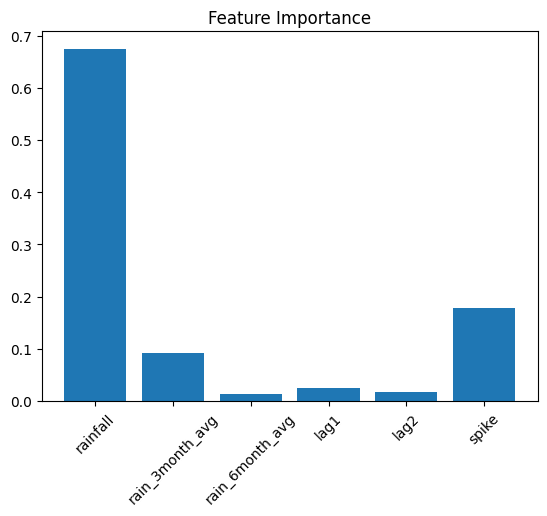

In [10]:
# Feature Importance
plt.figure()
plt.bar(X.columns, rf.feature_importances_)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [11]:
# Flood Risk Score (FRS)
df['FRS'] = rf.predict_proba(X)[:, 2]

df[['rainfall','FRS']].head()

,rainfall,FRS
5,12.88130,0.0
6,68.09300,1.0
7,16.58360,0.0
8,13.33910,0.0
9,3.10757,0.0
